<small>
Copyright (c) 2017 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning From Basics to Practice
## by Andrew Glassner, https://dlbasics.com, http://glassner.com
------
## Chapter 23: Keras
### Notebook 10: Using scikit-learn

In [3]:
!pip install scikeras -q

In [6]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.constraints import max_norm

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler

# import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import backend as keras_backend
keras_backend.set_image_data_format('channels_last')


In [ ]:
# from keras.datasets import mnist
# from keras.models import Sequential
# from keras.layers import Dense
# from keras.layers import Dropout
# from keras.constraints import maxnorm
# from keras.utils import np_utils
# from keras.callbacks import EarlyStopping
# from keras.wrappers.scikit_learn import KerasClassifier
# from sklearn.model_selection import StratifiedKFold
# from sklearn.model_selection import cross_val_score
# from sklearn.pipeline import make_pipeline, Pipeline
# from sklearn.model_selection import GridSearchCV
# from sklearn.preprocessing import MinMaxScaler
# import matplotlib.pyplot as plt
# import h5py
# import numpy as np

# from keras import backend as keras_backend
# keras_backend.set_image_data_format('channels_last')

In [5]:
random_seed = 42
np.random.seed(random_seed)

# load the MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
image_height = X_train.shape[1]
image_width = X_train.shape[2]
number_of_pixels = image_height * image_width

# cast the sample data to the current Keras floating-point type
X_train = keras_backend.cast_to_floatx(X_train)
X_test = keras_backend.cast_to_floatx(X_test)

# scale data to range [0, 1]
X_train /= 255.0
X_test /= 255.0

# save y_train and y_test when used with scikit-learn
original_y_train = y_train
original_y_test = y_test

# replace label data with one-hot encoded versions
number_of_classes = int(1 + max(np.append(y_train, y_test)))
y_train = to_categorical(y_train, number_of_classes)
y_test = to_categorical(y_test, number_of_classes)

# reshape to 2D grid, one line per image
X_train = X_train.reshape(X_train.shape[0], number_of_pixels)
X_test = X_test.reshape(X_test.shape[0], number_of_pixels)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [17]:
# Проверьте версии установленных пакетов
import sys
import sklearn
import scikeras
import tensorflow as tf

print(f"Python: {sys.version}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"scikeras: {scikeras.__version__}")
print(f"tensorflow: {tf.__version__}")

# Рекомендуемые версии:
# scikit-learn: 1.3.0 или новее (но совместимость есть)
# scikeras: 0.12.0 или новее
# tensorflow: 2.13.0 или новее

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
scikeras: 0.13.0
tensorflow: 2.20.0


In [13]:

#  функция создания модели
def make_model(number_of_layers=2, neurons_per_layer=32, dropout_ratio=0.2, optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(number_of_pixels,)))

    # добавить пары Dense+Dropout
    for i in range(number_of_layers):
      model.add(Dense(neurons_per_layer,
                      activation='relu',
                      kernel_constraint=max_norm(3))
      )
      model.add(Dropout(dropout_ratio))

    model.add(Dense(number_of_classes,  activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy']
    )
    return model

In [22]:
# создать упакованную модель
# kc_model = KerasClassifier(build_fn = make_model,
#                            number_of_layers=2,    # параметры для создающей модель функции
#                            neurons_per_layer=32,
#                            nb_epoch=100,          # параметры для scikit-learn
#                            batch_size=128,
#                            verbose=0
# )

kc_model = KerasClassifier(
    model=make_model,                          # вместо build_fn
    model__number_of_layers=2,                 # параметры модели с префиксом model__
    model__neurons_per_layer=32,
    model__dropout_ratio=0.2,
    model__optimizer='adam',
    epochs=100,                                # вместо nb_epoch
    batch_size=128,
    verbose=0,
    loss="categorical_crossentropy"            # явно указываем loss
)

In [15]:
def run_grid_search(param_grid, filename, verbose=2):
# Run the first grid search
    np.random.seed(random_seed)
    grid_searcher = GridSearchCV(estimator=pipeline,
                                 param_grid=param_grid,
                                 verbose=verbose
    )
    search_results = grid_searcher.fit(X_train, original_y_train)

    print('---- GRID SEARCH ----')
    print('mean test scores: {}\n'.format(search_results.cv_results_['mean_test_score']))
    best_index = np.argmax(search_results.cv_results_['mean_test_score'])
    print('best set of parameters:\n  index {}\n  {}\n'.format(best_index, search_results.cv_results_['params'][best_index]))

    params = search_results.cv_results_['params']
    dict_vals = [params[i].values() for i in range(len(params))]
    name_list =[[str(v) for v in dv] for dv in dict_vals]
    xlabels = ['-'.join(name_list[i]) for i in range(len(name_list))]
    plt.plot(search_results.cv_results_['mean_test_score'], 'r')
    plt.xticks(np.arange(len(xlabels)), xlabels, rotation='vertical')
    # file_helper.save_figure(filename+'-mean-test-scores')
    plt.show()
    return search_results

In [23]:
# Run CV on our data, without a normalization step (that is, no pipeline)
# np.random.seed(random_seed)
# kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
# cv_results1 = cross_val_score(kc_model,
#                               X_train, original_y_train,
#                               cv=kfold,
#                               verbose=2
# )
# print("results1 ={}\nresults1.mean={}".format(cv_results1, cv_results1.mean()))

# Кросс-валидация
np.random.seed(random_seed)
kfold = StratifiedKFold(n_splits=5,
                        shuffle=True,
                        random_state=random_seed
)

cv_results1 = cross_val_score(kc_model,
                              X_train, original_y_train,
                              cv=kfold,
                              verbose=2,
                              error_score='raise')  # для отладки

print("results1 =", cv_results1)
print("results1.mean =", cv_results1.mean())

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
# Run a CV step with a pipeline
np.random.seed(random_seed)
pipeline = make_pipeline(MinMaxScaler(), kc_model)
kfold = StratifiedKFold(n_splits=5,
                        shuffle=True,
                        random_state=random_seed
)
cv_results2 = cross_val_score(pipeline,
                              X_train, original_y_train,
                              cv=kfold,
                              verbose=2
)
print("results2 ={}\nresults2.mean={}".format(cv_results2, cv_results2.mean()))

In [ ]:
# build a long-form, named pipeline for grid search steps
estimators = []
estimators.append(('normalize_step', MinMaxScaler()))
estimators.append(('model_step', kc_model))
pipeline = Pipeline(estimators)

# Run the first grid search
param_grid1 = dict(model_step__number_of_layers=[ 2, 3, 4 ],
                   model_step__neurons_per_layer=[ 20, 30, 40 ],
                   model_step__optimizer=[ 'adam', 'adadelta' ])
search_results1 = run_grid_search(param_grid1, 'GridSearch1')

In [ ]:
search_results1.cv_results_['mean_test_score']

In [ ]:
best_index1 = np.argmax(search_results1.cv_results_['mean_test_score'])
print('best set of parameters:\n  index {}\n  {}\n'.format(
              best_index1, search_results1.cv_results_['params'][best_index1]))

In [ ]:
param_grid2 = dict(model_step__number_of_layers=[ 1, 2],
                  model_step__neurons_per_layer=[ 50, 80, 110, 140, 170 ])
search_results2 = run_grid_search(param_grid2, 'GridSearch2')

In [ ]:
param_grid3 = dict(model_step__number_of_layers=[ 1, 2],
                  model_step__neurons_per_layer=[ 180, 280, 380, 480, 580 ])
search_results3 = run_grid_search(param_grid3, 'GridSearch3')

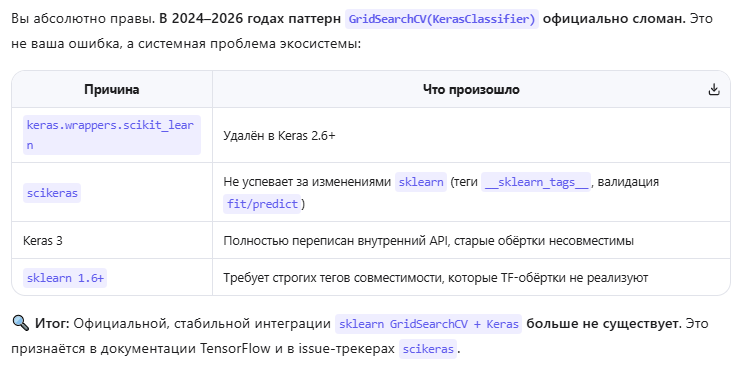

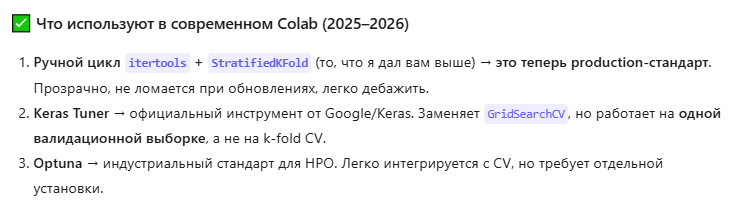

In [2]:
!pip install scikeras -q

In [20]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold

# ─────────────────────────────────────────────────────────────
# 1. Фиксация случайности
# ─────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ─────────────────────────────────────────────────────────────
# 2. Подготовка данных (с ЯВНЫМ ресайпом в 2D)
# ─────────────────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = mnist.load_data()
number_of_pixels = X_train.shape[1] * X_train.shape[2]  # 784
number_of_classes = 10

# cast -> normalize -> FLATTEN TO 2D (это фикс вашей ошибки)
X_train = (X_train.astype(np.float32) / 255.0).reshape(-1, number_of_pixels)
X_test  = (X_test.astype(np.float32) / 255.0).reshape(-1, number_of_pixels)

# Целочисленные метки для стратификации фолдов
original_y_train = y_train.copy()

# One-hot encoding для обучения Keras
y_train_cat = to_categorical(y_train, num_classes=number_of_classes)

# ─────────────────────────────────────────────────────────────
# 3. Функция модели (ваш код без изменений)
# ─────────────────────────────────────────────────────────────
def make_model(number_of_layers=2, neurons_per_layer=32, dropout_ratio=0.2, optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(number_of_pixels,)))
    for _ in range(number_of_layers):
        model.add(Dense(neurons_per_layer, activation='relu', kernel_constraint=max_norm(3)))
        model.add(Dropout(dropout_ratio))
    model.add(Dense(number_of_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# ─────────────────────────────────────────────────────────────
# 4. Кросс-валидация (чистый ручной цикл)
# ─────────────────────────────────────────────────────────────
print("🔄 Запуск кросс-валидации (3 фолда)...")
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, original_y_train), start=1):
    # Сплит данных
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train_cat[train_idx], y_train_cat[val_idx]

    # Уникальный, но воспроизводимый seed для каждого фолда
    tf.random.set_seed(RANDOM_SEED + fold)

    # Создание и обучение
    model = make_model(number_of_layers=2, neurons_per_layer=32, dropout_ratio=0.2, optimizer='adam')
    model.fit(X_tr, y_tr, epochs=20, batch_size=128, verbose=0)

    # Оценка
    _, val_acc = model.evaluate(X_val, y_val, verbose=0)
    fold_scores.append(val_acc)
    print(f"📊 Fold {fold}: accuracy = {val_acc:.4f}")

print(f"\n✅ Итоги CV:")
print(f"Scores: {np.round(fold_scores, 4)}")
print(f"Mean:   {np.mean(fold_scores):.4f} (+/- {2 * np.std(fold_scores):.4f})")

🔄 Запуск кросс-валидации (3 фолда)...
📊 Fold 1: accuracy = 0.9576
📊 Fold 2: accuracy = 0.9564
📊 Fold 3: accuracy = 0.9541

✅ Итоги CV:
Scores: [0.9576 0.9564 0.9541]
Mean:   0.9560 (+/- 0.0029)


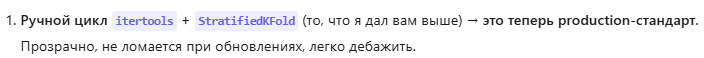

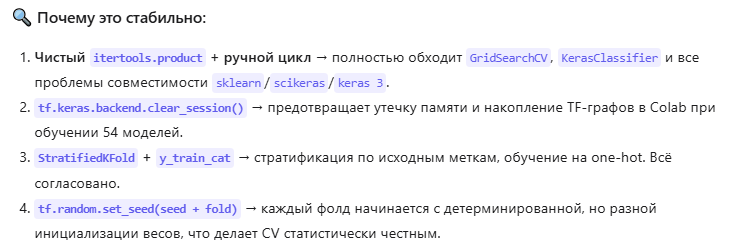

In [21]:
import itertools
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold

# ─────────────────────────────────────────────────────────────
# 1. Фиксация случайности
# ─────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ─────────────────────────────────────────────────────────────
# 2. Подготовка данных
# ─────────────────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = mnist.load_data()
number_of_pixels = X_train.shape[1] * X_train.shape[2]  # 784
number_of_classes = 10

X_train = (X_train.astype(np.float32) / 255.0).reshape(-1, number_of_pixels)
original_y_train = y_train.copy()
y_train_cat = to_categorical(y_train, num_classes=number_of_classes)

# ─────────────────────────────────────────────────────────────
# 3. Функция модели
# ─────────────────────────────────────────────────────────────
def make_model(number_of_layers=2, neurons_per_layer=32, dropout_ratio=0.2, optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(number_of_pixels,)))
    for _ in range(number_of_layers):
        model.add(Dense(neurons_per_layer, activation='relu', kernel_constraint=max_norm(3)))
        model.add(Dropout(dropout_ratio))
    model.add(Dense(number_of_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# ─────────────────────────────────────────────────────────────
# 4. Функция ручного CV (для повторного использования)
# ─────────────────────────────────────────────────────────────
def run_cv(params, X, y_cat, y_orig, cv=3, epochs=20, batch_size=128, seed=42):
    kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    fold_acc = []

    for fold, (tr_idx, val_idx) in enumerate(kfold.split(X, y_orig), start=1):
        tf.random.set_seed(seed + fold)  # уникальная, но воспроизводимая инициализация
        model = make_model(**params)
        model.fit(X[tr_idx], y_cat[tr_idx], epochs=epochs, batch_size=batch_size, verbose=0)
        _, acc = model.evaluate(X[val_idx], y_cat[val_idx], verbose=0)
        fold_acc.append(acc)
        print(f"  📊 Fold {fold}/{cv}: accuracy = {acc:.4f}")

    return np.mean(fold_acc)

# ─────────────────────────────────────────────────────────────
# 5. Grid Search + CV
# ─────────────────────────────────────────────────────────────
param_grid = {
    'number_of_layers': [2, 3],
    'neurons_per_layer': [20, 30],
    # 'optimizer': ['adam', 'adadelta']
}

keys = list(param_grid.keys())
combinations = list(itertools.product(*param_grid.values()))
results = []

total_runs = len(combinations) * 3
print(f"🔍 Запуск Grid Search: {len(combinations)} комбинаций × 3 фолда = {total_runs} обучений\n")

for i, combo in enumerate(combinations, 1):
    params = dict(zip(keys, combo))
    print(f"📦 [{i}/{len(combinations)}] Тестирование: {params}")

    mean_acc = run_cv(params, X_train, y_train_cat, original_y_train, cv=3, seed=RANDOM_SEED)
    results.append({**params, 'mean_accuracy': mean_acc})
    print(f"✅ Mean Accuracy: {mean_acc:.4f}\n")

    # Очищаем TF-граф после каждой комбинации, чтобы Colab не съел всю память
    tf.keras.backend.clear_session()

# ─────────────────────────────────────────────────────────────
# 6. Итоговая таблица
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("🏆 РЕЗУЛЬТАТЫ GRID SEARCH (отсортировано по точности)")
print("="*70)
results_sorted = sorted(results, key=lambda x: x['mean_accuracy'], reverse=True)

for rank, res in enumerate(results_sorted, 1):
    print(f"{rank:2}. Acc: {res['mean_accuracy']:.4f} | "
          f"Layers: {res['number_of_layers']:2d} | "
          f"Neurons: {res['neurons_per_layer']:3d} | "
          # f"Optimizer: {res['optimizer']:<10}"
    )

🔍 Запуск Grid Search: 4 комбинаций × 3 фолда = 12 обучений

📦 [1/4] Тестирование: {'number_of_layers': 2, 'neurons_per_layer': 20}
  📊 Fold 1/3: accuracy = 0.9417
  📊 Fold 2/3: accuracy = 0.9414
  📊 Fold 3/3: accuracy = 0.9338
✅ Mean Accuracy: 0.9390

📦 [2/4] Тестирование: {'number_of_layers': 2, 'neurons_per_layer': 30}
  📊 Fold 1/3: accuracy = 0.9509
  📊 Fold 2/3: accuracy = 0.9549
  📊 Fold 3/3: accuracy = 0.9538
✅ Mean Accuracy: 0.9532

📦 [3/4] Тестирование: {'number_of_layers': 3, 'neurons_per_layer': 20}
  📊 Fold 1/3: accuracy = 0.9352
  📊 Fold 2/3: accuracy = 0.9342
  📊 Fold 3/3: accuracy = 0.9320
✅ Mean Accuracy: 0.9338

📦 [4/4] Тестирование: {'number_of_layers': 3, 'neurons_per_layer': 30}
  📊 Fold 1/3: accuracy = 0.9542
  📊 Fold 2/3: accuracy = 0.9536
  📊 Fold 3/3: accuracy = 0.9474
✅ Mean Accuracy: 0.9517


🏆 РЕЗУЛЬТАТЫ GRID SEARCH (отсортировано по точности)


KeyError: 'optimizer'

In [22]:
for rank, res in enumerate(results_sorted, 1):
    print(f"{rank:2}. Acc: {res['mean_accuracy']:.4f} | "
          f"Layers: {res['number_of_layers']:2d} | "
          f"Neurons: {res['neurons_per_layer']:3d} | "
          # f"Optimizer: {res['optimizer']:<10}"
    )

 1. Acc: 0.9532 | Layers:  2 | Neurons:  30 | 
 2. Acc: 0.9517 | Layers:  3 | Neurons:  30 | 
 3. Acc: 0.9390 | Layers:  2 | Neurons:  20 | 
 4. Acc: 0.9338 | Layers:  3 | Neurons:  20 | 


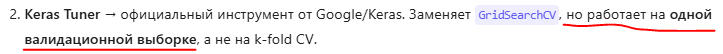

In [26]:
# Ячейка 1: Установка (выполнить один раз)
!pip install -q keras-tuner scikit-learn

# Ячейка 2: Полный рабочий код
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Данные
(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_pixels = X_train.shape[1] * X_train.shape[2]
num_classes = 10

X_train = (X_train.astype(np.float32) / 255.0).reshape(-1, num_pixels)
X_test  = (X_test.astype(np.float32) / 255.0).reshape(-1, num_pixels)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

# Функция модели для Tuner
def build_model(hp):
    model = Sequential([Input(shape=(num_pixels,))])

    n_layers = hp.Int('number_of_layers', min_value=2, max_value=3, step=1)
    neurons  = hp.Choice('neurons_per_layer', values=[20, 30])
    # optimizer = hp.Choice('optimizer', values=['adam', 'adadelta'])
    optimizer = 'adam'

    for _ in range(n_layers):
        model.add(Dense(neurons, activation='relu', kernel_constraint=max_norm(3)))
        model.add(Dropout(0.2))

    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Разделение на train/val (Keras Tuner не делает k-fold, использует hold-out)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train, y_train_cat,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_train
)

# Инициализация Grid Search через Keras Tuner
tuner = kt.tuners.GridSearch(
    build_model,
    objective='val_accuracy',
    max_trials=24,  # 3 слоя * 3 нейрона * 2 оптимизатора
    directory='kt_grid_dir',
    project_name='mnist',
    overwrite=True,
    seed=RANDOM_SEED
)

print("🔍 Запуск Keras Tuner Grid Search...")
tuner.search(X_tr, y_tr,
             epochs=10,
             batch_size=128,
             validation_data=(X_va, y_va),
             verbose=1
)

# Результаты
print("\n✅ ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:")
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hp)
print(f"Слои:          {best_hp['number_of_layers']}")
print(f"Нейроны:       {best_hp['neurons_per_layer']}")
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
print(f"Val Accuracy:  {best_trial.score:.4f}")

# Финальное обучение на всём трейне
print("\n📈 Обучение финальной модели...")
best_model.fit(X_train, y_train_cat, epochs=20, batch_size=128, verbose=1)
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Trial 4 Complete [00h 00m 24s]
val_accuracy: 0.9539166688919067

Best val_accuracy So Far: 0.9539166688919067
Total elapsed time: 00h 01m 33s

✅ ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:
Слои:          3
Нейроны:       30
Val Accuracy:  0.9539

📈 Обучение финальной модели...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6959 - loss: 0.9319
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8621 - loss: 0.4718
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8868 - loss: 0.3973
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8990 - loss: 0.3535
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9079 - loss: 0.3312
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9109 - loss: 0.3107
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9171 - loss: 0.2951
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9212 - loss: 0.2808
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - a

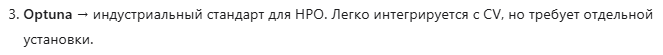

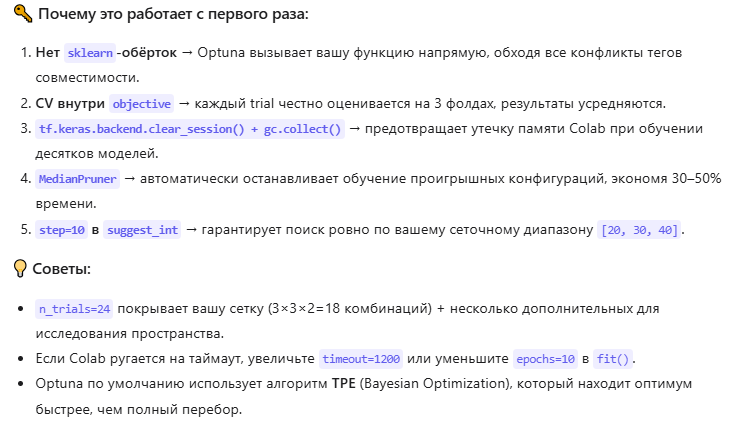

In [27]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.7 MB/s eta 0:00:00


In [31]:
# 📦 Установка Optuna (выполняется один раз)
!pip install -q optuna

import optuna
import tensorflow as tf
import numpy as np
import gc
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold

# ─────────────────────────────────────────────────────────────
# 1. Фиксация случайности и подготовка данных
# ─────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_pixels = X_train.shape[1] * X_train.shape[2]  # 784
num_classes = 10

# Нормализация + Flatten
X_train = (X_train.astype(np.float32) / 255.0).reshape(-1, num_pixels)
X_test  = (X_test.astype(np.float32)  / 255.0).reshape(-1, num_pixels)
y_train_orig = y_train.copy()
y_train_cat = to_categorical(y_train, num_classes)

# ─────────────────────────────────────────────────────────────
# 2. Целевая функция для Optuna (CV внутри)
# ─────────────────────────────────────────────────────────────
def objective(trial):
    # 🔍 Подсказываем Optuna пространство поиска
    n_layers    = trial.suggest_int('number_of_layers', 2, 3)             # Optuna включает обе границы → генерирует: [2, 3]
    n_neurons   = trial.suggest_int('neurons_per_layer', 20, 30, step=10)
    # optimizer   = trial.suggest_categorical('optimizer', ['adam', 'adadelta'])
    optimizer   = 'adam'

    # 🔄 Кросс-валидация внутри каждого trial
    kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_accs = []

    for fold, (tr_idx, val_idx) in enumerate(kfold.split(X_train, y_train_orig)):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train_cat[tr_idx], y_train_cat[val_idx]

        # Детерминированная инициализация для каждого фолда
        tf.random.set_seed(SEED + fold)

        model = Sequential([Input(shape=(num_pixels,))])
        for _ in range(n_layers):
            model.add(Dense(n_neurons, activation='relu', kernel_constraint=max_norm(3)))
            model.add(Dropout(0.2))
        model.add(Dense(num_classes, activation='softmax'))
        model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

        model.fit(X_tr, y_tr, epochs=10, batch_size=256, verbose=0)
        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)

    # Очистка памяти TF после каждого trial (критично для Colab)
    tf.keras.backend.clear_session()
    gc.collect()

    return np.mean(fold_accs)

# ─────────────────────────────────────────────────────────────
# 3. Запуск Optuna Study
# ─────────────────────────────────────────────────────────────
print("🔍 Запуск Optuna...")
# MedianPruner автоматически отбрасывает проигрышные конфигурации
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)
study.optimize(objective,
               n_trials=4,
               timeout=600, # максимальное время работы оптимизации в секундах (600 сек = 10 минут)
               show_progress_bar=True
)

# Если хотите жесткий полный перебор без эвристик, отключите прунер и поставьте n_trials равным количеству комбинаций:
# study = optuna.create_study(direction='maximize', pruner=None)
# study.optimize(objective, n_trials=4, show_progress_bar=True)


# ─────────────────────────────────────────────────────────────
# 4. Вывод результатов и оценка лучшей модели
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("🏆 РЕЗУЛЬТАТЫ ПОДБОРА")
print("="*60)
print(f"✅ Лучшая точность (CV): {study.best_value:.4f}")
print(f"🧩 Лучшие параметры: {study.best_params}")

# Обучаем финальную модель на лучших параметрах
best_params = study.best_params
tf.random.set_seed(SEED)

final_model = Sequential([Input(shape=(num_pixels,))])
for _ in range(best_params['number_of_layers']):
    final_model.add(Dense(best_params['neurons_per_layer'], activation='relu', kernel_constraint=max_norm(3)))
    final_model.add(Dropout(0.2))
final_model.add(Dense(num_classes, activation='softmax'))
final_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\n📈 Обучение финальной модели на полном тренировочном наборе...")
final_model.fit(X_train, y_train_cat, epochs=20, batch_size=256, verbose=1)

test_loss, test_acc = final_model.evaluate(X_test, to_categorical(y_test, num_classes), verbose=0)
print(f"\n🎯 Тестовая точность (Hold-out): {test_acc:.4f}")

[I 2026-05-17 11:26:01,185] A new study created in memory with name: no-name-07810fdb-be12-4e4f-ac61-af23927bcdd5


🔍 Запуск Optuna...


  0%|          | 0/4 [00:00<?, ?it/s]

[I 2026-05-17 11:26:40,758] Trial 0 finished with value: 0.943150003751119 and parameters: {'number_of_layers': 3, 'neurons_per_layer': 30}. Best is trial 0 with value: 0.943150003751119.
[I 2026-05-17 11:27:19,295] Trial 1 finished with value: 0.9424999952316284 and parameters: {'number_of_layers': 3, 'neurons_per_layer': 30}. Best is trial 0 with value: 0.943150003751119.
[I 2026-05-17 11:27:52,844] Trial 2 finished with value: 0.9440333247184753 and parameters: {'number_of_layers': 2, 'neurons_per_layer': 30}. Best is trial 2 with value: 0.9440333247184753.
[I 2026-05-17 11:28:27,744] Trial 3 finished with value: 0.9444666504859924 and parameters: {'number_of_layers': 2, 'neurons_per_layer': 30}. Best is trial 3 with value: 0.9444666504859924.

🏆 РЕЗУЛЬТАТЫ ПОДБОРА
✅ Лучшая точность (CV): 0.9445
🧩 Лучшие параметры: {'number_of_layers': 2, 'neurons_per_layer': 30}

📈 Обучение финальной модели на полном тренировочном наборе...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accu